# Data Sampling

In [8]:
import json
import random
import pandas as pd
from pathlib import Path

# -----------------------------
# Reservoir sampling (keeps only k users in memory)
# and stores the selected fields so we can write users_10k.csv directly.
# -----------------------------
def reservoir_sample_users(
    user_jsonl_path,
    k=10_000,
    seed=42,
    keep_fields=("user_id", "review_count", "yelping_since", "average_stars", "elite", "fans"),
):
    random.seed(seed)
    sample = []
    n = 0

    user_jsonl_path = Path(user_jsonl_path)

    with user_jsonl_path.open("r", encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)
            n += 1

            row = {field: obj.get(field) for field in keep_fields}

            if len(sample) < k:
                sample.append(row)
            else:
                j = random.randint(1, n)  # 1..n
                if j <= k:
                    sample[j - 1] = row

    return sample


# ✅ EDIT THIS to your actual path
USER_JSON = r"C:\Users\lebro\Downloads\Yelp-JSON\Yelp JSON\yelp_dataset\yelp_academic_dataset_user.json"

# output files (write into current repo folder)
OUT_USERS_CSV = "users_10k.csv"
OUT_USERIDS_TXT = "user_ids_10k.txt"

sample_rows = reservoir_sample_users(
    USER_JSON,
    k=10_000,
    seed=42,
    keep_fields=("user_id", "review_count", "yelping_since", "average_stars", "elite", "fans"),
)

users_10k = pd.DataFrame(sample_rows)

# Sanity checks
print("✅ sampled rows:", len(users_10k))
print("✅ unique user_id:", users_10k["user_id"].nunique())
print(users_10k.head())

# Save users_10k.csv
users_10k.to_csv(OUT_USERS_CSV, index=False)
print(f"✅ Saved {OUT_USERS_CSV}")

# Save user_ids_10k.txt (one id per line) for quick filtering of other JSONL files
users_10k["user_id"].dropna().to_csv(OUT_USERIDS_TXT, index=False, header=False)
print(f"✅ Saved {OUT_USERIDS_TXT}")

✅ sampled rows: 10000
✅ unique user_id: 10000
                  user_id  review_count        yelping_since  average_stars  \
0  _1FclWG2YIrHlM9jxjetGw             2  2016-04-23 21:52:49            3.0   
1  w-dLZFsu2bsILlpKH9Vksg             1  2011-12-11 03:42:59            5.0   
2  FzGdbYxbCzh_X6-e53GHGA             1  2012-01-01 17:55:00            4.0   
3  Br4afMgQnpTgFVnuaplviA             4  2015-07-06 23:53:59            3.0   
4  f577LP73h5Vp41miiy273Q             2  2018-05-30 23:41:09            3.0   

  elite  fans  
0           0  
1           0  
2           1  
3           0  
4           0  
✅ Saved users_10k.csv
✅ Saved user_ids_10k.txt


Stream-filter reviews/tips/checkins and build business subset

In [9]:
import json
import csv

def load_user_ids_txt(path):
    """Load user_ids_10k.txt (one id per line) into a Python set."""
    user_ids = set()
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            uid = line.strip()
            if uid:
                user_ids.add(uid)
    return user_ids


def stream_filter_jsonl_by_user_ids(
    path,
    user_ids_set,
    out_csv,
    keep_cols,
    user_id_key="user_id",
    biz_id_key="business_id",
):
    """
    Stream-read a JSONL file, keep rows whose user_id is in user_ids_set,
    write directly to CSV (no big memory usage),
    and collect business_ids while streaming.
    """
    biz_ids = set()
    kept = 0

    with open(path, "r", encoding="utf-8") as fin, open(out_csv, "w", newline="", encoding="utf-8") as fout:
        writer = csv.DictWriter(fout, fieldnames=keep_cols)
        writer.writeheader()

        for line in fin:
            obj = json.loads(line)
            uid = obj.get(user_id_key)
            if uid in user_ids_set:
                row = {k: obj.get(k) for k in keep_cols}
                writer.writerow(row)
                kept += 1

                bid = obj.get(biz_id_key)
                if bid:
                    biz_ids.add(bid)

    return kept, biz_ids


# ---- usage ----

# ✅ Load USER_IDS from user_ids_10k.txt
USER_IDS_TXT = "user_ids_10k.txt"   # or full path if it's elsewhere
USER_IDS = load_user_ids_txt(USER_IDS_TXT)

print("✅ loaded user ids:", len(USER_IDS))

reviews_path = r"C:\Users\lebro\Downloads\Yelp-JSON\Yelp JSON\yelp_dataset\yelp_academic_dataset_review.json"
tips_path    = r"C:\Users\lebro\Downloads\Yelp-JSON\Yelp JSON\yelp_dataset\yelp_academic_dataset_tip.json"

reviews_cols = ["review_id","user_id","business_id","stars","date","useful","funny","cool"]
tips_cols    = ["user_id","business_id","date","compliment_count","text"]

n_reviews, biz_from_reviews = stream_filter_jsonl_by_user_ids(
    reviews_path, USER_IDS, "reviews_10k.csv", keep_cols=reviews_cols
)

n_tips, biz_from_tips = stream_filter_jsonl_by_user_ids(
    tips_path, USER_IDS, "tips_10k.csv", keep_cols=tips_cols
)

biz_ids = biz_from_reviews | biz_from_tips

print("✅ reviews kept:", n_reviews)
print("✅ tips kept:", n_tips)
print("✅ businesses referenced:", len(biz_ids))

✅ loaded user ids: 10000
✅ reviews kept: 35017
✅ tips kept: 5423
✅ businesses referenced: 23597


In [10]:
import json
import csv

def stream_filter_businesses(path, biz_ids_set, out_csv, keep_cols):
    kept = 0
    with open(path, "r", encoding="utf-8") as fin, open(out_csv, "w", newline="", encoding="utf-8") as fout:
        writer = csv.DictWriter(fout, fieldnames=keep_cols)
        writer.writeheader()

        for line in fin:
            obj = json.loads(line)
            if obj.get("business_id") in biz_ids_set:
                row = {k: obj.get(k) for k in keep_cols}
                writer.writerow(row)
                kept += 1
    return kept

business_cols = ["business_id","name","city","state","latitude","longitude","stars","review_count","categories","is_open"]

n_biz = stream_filter_businesses(
    r"C:\Users\lebro\Downloads\Yelp-JSON\Yelp JSON\yelp_dataset\yelp_academic_dataset_business.json",
    biz_ids,
    "business_10k.csv",
    keep_cols=business_cols
)

print("✅ businesses kept:", n_biz)

✅ businesses kept: 23597


In [11]:
import json
import csv

def stream_filter_checkins_by_biz(path, biz_ids_set, out_csv):
    kept = 0
    with open(path, "r", encoding="utf-8") as fin, open(out_csv, "w", newline="", encoding="utf-8") as fout:
        writer = csv.DictWriter(fout, fieldnames=["business_id", "date"])
        writer.writeheader()

        for line in fin:
            obj = json.loads(line)
            bid = obj.get("business_id")
            if bid in biz_ids_set:
                writer.writerow({"business_id": bid, "date": obj.get("date")})
                kept += 1

    return kept

checkins_path = r"C:\Users\lebro\Downloads\Yelp-JSON\Yelp JSON\yelp_dataset\yelp_academic_dataset_checkin.json"
n_checkins = stream_filter_checkins_by_biz(checkins_path, biz_ids, "checkin_10k.csv")
print("✅ checkins kept:", n_checkins)

✅ checkins kept: 22693


# Sanity Check

In [12]:
import pandas as pd

users = pd.read_csv("users_10k.csv")
reviews = pd.read_csv("reviews_10k.csv")
tips = pd.read_csv("tips_10k.csv")
biz = pd.read_csv("business_10k.csv")
checkins = pd.read_csv("checkin_10k.csv")

print(len(users), "users")
print(len(reviews), "reviews")
print(len(tips), "tips")
print(len(biz), "businesses")
print(len(checkins), "checkins")

10000 users
35017 reviews
5423 tips
23597 businesses
22693 checkins


In [13]:
print("users in reviews:", reviews.user_id.nunique())
print("users in tips:", tips.user_id.nunique())
print("businesses in reviews:", reviews.business_id.nunique())

users in reviews: 10000
users in tips: 1569
businesses in reviews: 22220


Unify visits

In [14]:
reviews_ev = reviews[["user_id","business_id","date"]].copy()
reviews_ev["type"] = "review"

tips_ev = tips[["user_id","business_id","date"]].copy()
tips_ev["type"] = "tip"

visits = pd.concat([reviews_ev, tips_ev], ignore_index=True)

Attach location

In [15]:
visits = visits.merge(
    biz[["business_id","latitude","longitude"]],
    on="business_id",
    how="left"
)

visits = visits.dropna(subset=["latitude","longitude"])

In [16]:
visits.head()

,user_id,business_id,date,type,latitude,longitude
0,cpp89UW0imv45y3a_O444w,34Eqv8jXgxg_EEwcsNgeeg,2014-05-25 22:33:02,review,34.415114,-119.694497
1,MVuNw-mO5on8PpO_I6QtKg,o7cD_sDA-Evj3Oh0zeH9nQ,2015-03-18 18:28:22,review,39.477210,-119.764903
2,sHm9bRvQ2QFL7teGnHiGEA,LktIfbmd3k0kDiWibGw7DQ,2013-12-07 21:31:24,review,39.925490,-86.089045
3,Rhk8owk3uhFTvzJdYbQ6Xg,vje0KIiE7vtpx7JzmBx5LQ,2015-10-08 13:21:55,review,27.769405,-82.767317
4,H2WhI7u2Zc-ozPnKBvhWwQ,-hVMfjPPEsSnga_gnYJx2w,2007-12-08 19:17:57,review,39.487580,-119.759306


# Exploratory Spatial Analysis

Visit count per user

In [17]:
user_counts = visits.groupby("user_id").size()
user_counts.describe()

count    10000.000000
mean         4.044000
std         13.165857
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        456.000000
dtype: float64

Plot BEFORE clustering

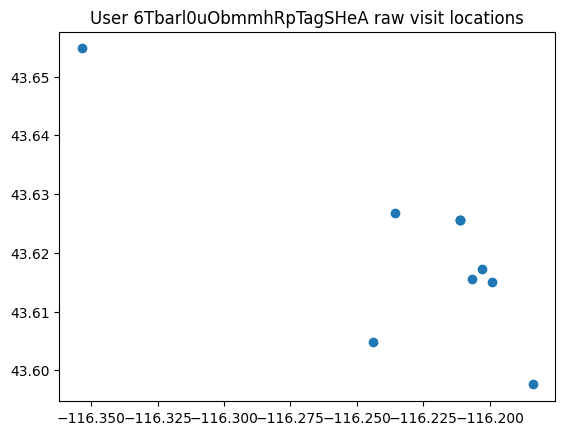

In [18]:
import matplotlib.pyplot as plt

uid = user_counts[user_counts >= 5].sample(1).index[0]
u = visits[visits.user_id == uid]

plt.scatter(u.longitude, u.latitude)
plt.title(f"User {uid} raw visit locations")
plt.show()

# Distance reasoning(WHY DBSCAN works)

Compute inner-visit distances

In [27]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd

MIN_VISITS = 5

def mean_nn_distance(df):
    coords = np.radians(df[["latitude","longitude"]].values)
    if len(coords) < 2:
        return None
    nn = NearestNeighbors(n_neighbors=2, metric="haversine").fit(coords)
    dists, _ = nn.kneighbors(coords)
    return (dists[:,1] * 6371).mean()

nn_dists = []

for uid, df in visits.groupby("user_id"):
    if len(df) >= MIN_VISITS:
        d = mean_nn_distance(df)
        if d is not None:
            nn_dists.append(d)

nn_series = pd.Series(nn_dists)

print(nn_series.describe())
print(nn_series.quantile([0.25, 0.5, 0.75, 0.9, 0.95]))

count    1680.000000
mean       22.705279
std        76.499597
min         0.000000
25%         1.255527
50%         2.711690
75%         5.690519
max       755.907871
dtype: float64
0.25      1.255527
0.50      2.711690
0.75      5.690519
0.90     38.241135
0.95    137.875344
dtype: float64


# Doing DBSCAN

In [21]:
from sklearn.cluster import DBSCAN

def cluster_user(df, eps_km=1.0, min_samples=3):
    coords = np.radians(df[["latitude","longitude"]].values)
    db = DBSCAN(
        eps=eps_km / 6371,
        min_samples=min_samples,
        metric="haversine"
    ).fit(coords)
    return db.labels_

In [22]:
u["cluster"] = cluster_user(u)

C:\Users\lebro\AppData\Local\Temp\ipykernel_33376\3576503230.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  u["cluster"] = cluster_user(u)


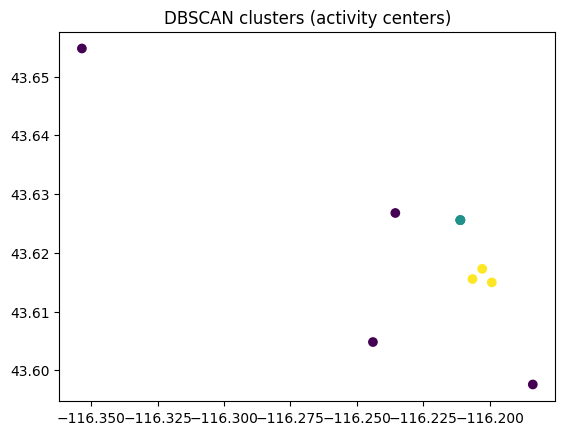

In [23]:
plt.scatter(u.longitude, u.latitude, c=u.cluster)
plt.title("DBSCAN clusters (activity centers)")
plt.show()

# Population-level analysis

Count clusters per user

In [24]:
def count_clusters(labels):
    return len(set(labels) - {-1})

cluster_stats = []

for uid, df in visits.groupby("user_id"):
    if len(df) < 3:
        continue
    labels = cluster_user(df)
    cluster_stats.append({
        "user_id": uid,
        "n_centers": count_clusters(labels)
    })

cluster_df = pd.DataFrame(cluster_stats)

Distribution

In [25]:
cluster_df["n_centers"].value_counts().sort_index()

n_centers
0     1973
1      725
2      191
3       64
4       33
5       16
6       12
7        5
8        7
9        5
10       4
11       7
12       1
13       3
16       1
17       2
18       2
19       1
20       1
22       1
36       1
Name: count, dtype: int64